In [10]:
import pandas as pd
from sklearn import datasets
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [7]:
titanic=sns.load_dataset("titanic")
features=["pclass","sex","fare","embarked","age"]
target=["survived"]
# handle missing Data
imp_median=SimpleImputer(strategy="median")
titanic["age"]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

# Encode
le=LabelEncoder()
titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

X=titanic[features]
y=titanic["survived"]

# train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [12]:
# Decision Tree Classifier
model=DecisionTreeRegressor()
model.fit(X_train,y_train)

y_pred_test=model.predict(X_test)
y_pred_train=model.predict(X_train)

print("Training Accuracy: ",r2_score(y_train,y_pred_train)*100)
print("Testing Accuracy: ",r2_score(y_test,y_pred_test)*100)


Training Accuracy:  94.64340931177667
Testing Accuracy:  3.5351873386450405


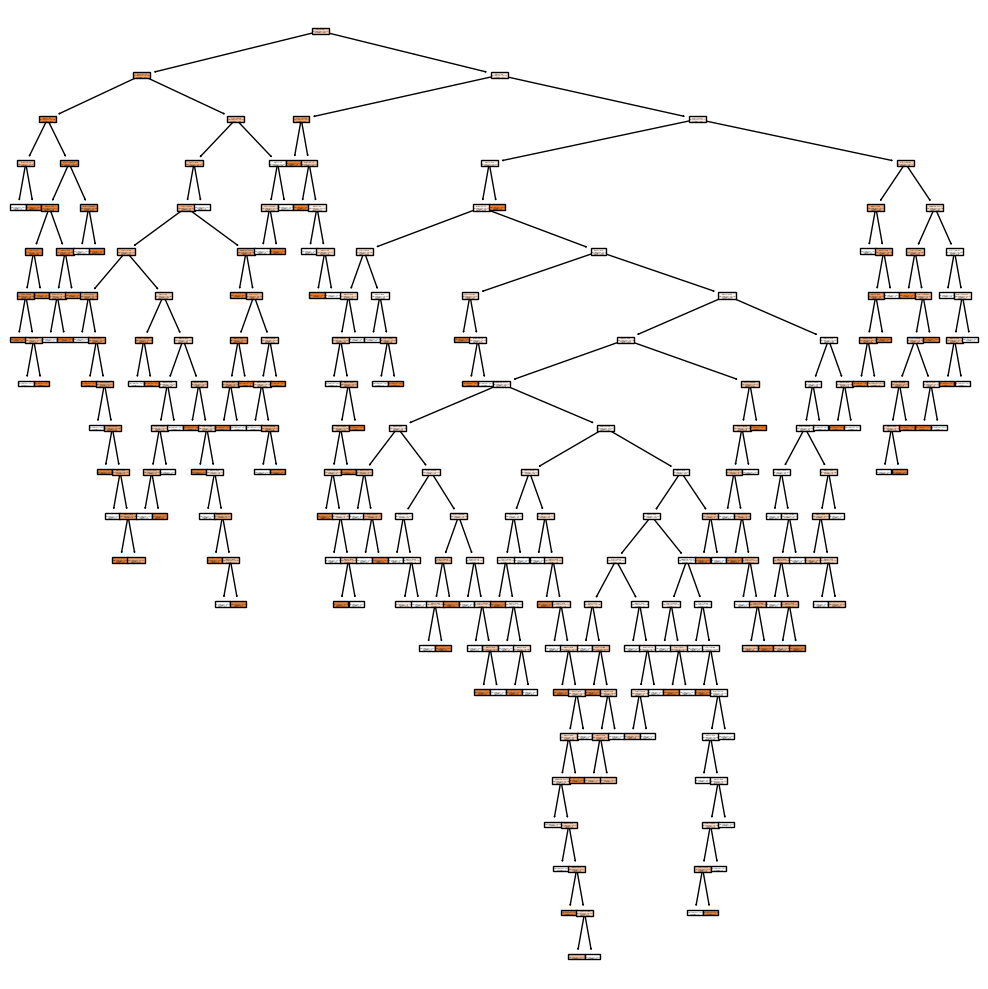

In [14]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(
    n_estimators=601,
    oob_score=True,
    max_depth=4
)
rf.fit(X_train,y_train)

,n_estimators,601
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [20]:
y_pred=rf.predict(X_test)
print("Testing Acccuracy", r2_score(y_test,y_pred))
print("OOB Score", rf.oob_score_)

Testing Acccuracy 0.42461501134513413
OOB Score 0.44578259276764554
